In [1]:
# Findspark
import findspark
findspark.init()

#### Create Spark Session:

In [64]:
import os
import pandas as pd
import plotly.express as px
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from pyspark.sql.functions import col, sum as spark_sum, avg, cast, count, when, isnan, trim, lit, lower, \
countDistinct, row_number, try_to_date, try_to_timestamp, coalesce, rank, dense_rank, year, month, day, current_date, round, \
max as spark_max, min as spark_min

spark = SparkSession.builder.appName("ENDB_Assignment") \
    .config("spark.sql.adaptive.enabled", "false") \
    .config("spark.ui.enabled", "true") \
    .config("spark.ui.port", "4040") \
    .config("spark.ui.showConsoleProgress", "true") \
    .getOrCreate()

#### Read CSV data:

In [3]:
def read_src_data(path):
    
    # Using pandas as pyspark.read.csv not working in my local
    # path = "dataset/nyc_jobs.csv"
    pandas_df = pd.read_csv(path)
    raw_df = spark.createDataFrame(pandas_df)
    print("Schema:")
    raw_df.printSchema()                                   # Print the Schema
    return raw_df

#### Analysis of source columns:

In [4]:
# Numeric values : null -> possible || nan   -> possible
# String values  : null -> possible || blank -> possible      || nan -> not possible
# Dates values   : null -> possible || nan   -> not possible
# Boolean values : null -> possible || nan   -> not possible

# Function to perform analysis on the data.
def col_analysis(raw_df):

    # Get the column list
    col_list = raw_df.columns

    # No need to run as analysis already presented in My_Document.md
    for i in col_list:
        col_name = col(i)

        print(f"{i}: \n")
        # Analysis of data: null count, nan count, blank count, total count
        # additional analysis present in My_Document.md
        count_df = raw_df.agg(spark_sum(when(col_name.isNull(), lit(1)).otherwise(lit(0))).alias("null_count")
                              # , spark_sum(when(isnan(col_name), lit(1)).otherwise(lit(0))).alias("nan_count")
                              , spark_sum(when((trim(col_name) == "nan") | (trim(col_name) == "null"), lit(1)).otherwise(lit(0))).alias("nan_count")
                              , spark_sum(when((col_name.isNotNull()) & (trim(col_name) == ""), lit(1)).otherwise(lit(0))).alias("blank_count")
                              , count(col_name).alias("total_count")
                              , countDistinct(col_name).alias("distinct_cnt"))

        count_df.show()

#### 1. Deduplication of data:

In [5]:
# Step 1: deduplicate the data by keeping only the latest version of the job posting

def deduplicate_data(raw_df):
    
    # Partitioned by Jod ID (unique key) and ordered descending by Posting Date (latest updated version of the posting)
    window_spec = Window.partitionBy(col("Job ID")).orderBy(col("Posting Date").desc())

    # Use row_number to number the rows and then keep only the latest row
    deduped_df = raw_df.withColumn("row_num", row_number().over(window_spec)).filter(col("row_num") == 1).drop(col("row_num"))

    return deduped_df

#### 2. Cast and Rename Columns:

In [6]:
# Step 2: rename and typecast columns

def cast_rename_col(deduped_df):
    
    # Column "Recruitment Contact" is completely empty and can therefore be dropped from the data.
    renamed_df = deduped_df.select(col("Job ID").cast("int").alias("job_id")
                                   , col("Agency").alias("agency")
                                   , col("Posting Type").alias("posting_type")
    							   , col("# Of Positions").cast("int").alias("open_positions")
    							   , col("Business Title").alias("business_title")
    							   , col("Civil Service Title").alias("civil_service_title")
    							   , col("Title Code No").alias("title_code_no")
    							   , col("Level").alias("level")
    							   , col("Job Category").alias("job_category")
    							   , col("Full-Time/Part-Time indicator").alias("employment_type")
    							   , col("Salary Range From").cast("decimal(10,2)").alias("min_salary")
    							   , col("Salary Range To").cast("decimal(10,2)").alias("max_salary")
    							   , col("Salary Frequency").alias("salary_frequency")
    							   , col("Work Location").alias("work_location")
    							   , col("Division/Work Unit").alias("division")
    							   , col("Job Description").alias("job_description")
    							   , col("Minimum Qual Requirements").alias("min_qualification")
    							   , col("Preferred Skills").alias("preferred_skills")
    							   , col("Additional Information").alias("additional_info")
    							   , col("To Apply").alias("how_to_apply")
    							   , col("Hours/Shift").alias("job_timings")
    							   , col("Work Location 1").alias("work_location_ext")
    							   , col("Residency Requirement").alias("residency_requirement")
    							   , try_to_timestamp(col("Posting Date")).alias("Posting Date")
    							   , try_to_timestamp(col("Post Until")).alias("closing_date")
    							   , try_to_timestamp(col("Posting Updated")).alias("Posting Updated")
    							   , try_to_timestamp(col("Process Date")).alias("Process Date"))

    return renamed_df

#### 3. Modify/Clean column values:

In [7]:
# Step 3: data wrangling (filter null, fill missing values, replace null with unknowns)

def data_wrangling(renamed_df):
    
    # Replaced **nan** values with **Unknown** || use **coalesce** for timestamp fields || **drop** columns no longer required
    cleaned_df = renamed_df.withColumn("job_category", when(lower(trim(col("job_category"))) == "nan", "Unknown").otherwise(col("job_category"))) \
        .withColumn("employment_type", when(lower(trim(col("employment_type"))) == "nan", "Unknown").otherwise(col("employment_type"))) \
        .withColumn("min_qualification", when(lower(trim(col("min_qualification"))) == "nan", "Unknown").otherwise(col("min_qualification"))) \
        .withColumn("preferred_skills", when(lower(trim(col("preferred_skills"))) == "nan", "Unknown").otherwise(col("preferred_skills"))) \
        .withColumn("additional_info", when(lower(trim(col("additional_info"))) == "nan", "Unknown").otherwise(col("additional_info"))) \
        .withColumn("how_to_apply", when(lower(trim(col("how_to_apply"))) == "nan", "Unknown").otherwise(col("how_to_apply"))) \
        .withColumn("job_timings", when(lower(trim(col("job_timings"))) == "nan", "Unknown").otherwise(col("job_timings"))) \
        .withColumn("work_location_ext", when(lower(trim(col("work_location_ext"))) == "nan", "Unknown").otherwise(col("work_location_ext"))) \
        .withColumn("residency_requirement", when(lower(trim(col("residency_requirement"))) == "nan", "Unknown").otherwise(col("residency_requirement"))) \
        .withColumn("posting_date", coalesce(col("Posting Date"), col("Process Date"), col("Posting Updated"))) \
        .withColumn("updated_on", coalesce(col("Posting Updated"), col("Posting Date"), col("Process Date"))) \
        .withColumn("process_date", coalesce(col("Process Date"), col("Posting Date"), col("Posting Updated"))) \
        .drop(col("Posting Date"), col("Posting Updated"), col("Process Date"))

    # Modify column values to reflect correct meaning
    cleaned_df = cleaned_df.withColumn("employment_type", when(lower(trim(col("employment_type"))) == "f", "Full_Time") \
        .when(lower(trim(col("employment_type"))) == 'p', "Part_Time").otherwise(col("employment_type")))

    return cleaned_df

#### 5. KIPs needed:

In [76]:
# 1. Number of jobs posting per category (Top 10)
def post_per_category(cleaned_df):
    
    post_per_cat_df = cleaned_df.groupBy(col("job_category")).agg(count("*").alias("no_of_jobs")).orderBy(col("no_of_jobs").desc()).limit(10)
    # post_per_cat_df.show()

    # Visualisation
    job_category_count = post_per_cat_df.toPandas()

    fig = px.bar(
        job_category_count, 
        x='job_category', 
        y='no_of_jobs',
        title='NYC Jobs: Job Postings per Category',
        color='job_category',
        color_discrete_sequence=px.colors.qualitative.Set3,  # Discrete palette
        text_auto=True,
        labels={'no_of_jobs': 'Number of Jobs', 'job_category': 'Job Category'}
    )

    fig.update_layout(
        xaxis_title="Job Category",
        yaxis_title="Number of Jobs",
        showlegend=False,
        height=500
    )

    fig.show()



# 2. Salary Distribution per job category
def salary_dist_category(cleaned_df):
    pass


# 3. Correlation between higher degree and salary
def salary_dist_category(cleaned_df):
    pass


# 4. Highest Salary Job Posting per agency
def highest_sal_per_agency(cleaned_df):

    window_spec = Window.partitionBy(col("agency")).orderBy(col("max_salary").desc())
    highest_sal_df = cleaned_df.withColumn("row_num", row_number().over(window_spec)).filter(col("row_num") == 1).drop(col("row_num")) \
        .select(col("agency"), col("max_salary")).orderBy(col("max_salary").desc())
    # highest_sal_df.show()

    # For visualisation we will use only the Top 10 Highest Salary per posting
    highest_sal_df = highest_sal_df.limit(10)

    # Visualisation
    highest_salary = highest_sal_df.toPandas()
    fig = px.bar(highest_salary, 
                 x='max_salary', 
                 y='agency',  # Horizontal bars
                 orientation='h',
                 hover_data=['agency'],
                 title='NYC Jobs: Highest Salary Job Posting per Agency',
                 text_auto=True,
                 color='max_salary',
                 color_continuous_scale='viridis')

    fig.update_traces(textposition='outside')
    fig.update_layout(
        xaxis_title="Highest Salary From ($)",
        yaxis_title="Agency",
        height=600,
        showlegend=False,
        yaxis={'categoryorder':'total descending'}
    )
    fig.show()


# 5. Average Salary of Job Posting per Agency for last 2 years
def avg_sal(cleaned_df):

    # Find out the max date/year from the data
    max_date = cleaned_df.agg(spark_max("posting_date").alias("max_date")).collect()[0][0]
    max_year = max_date.year
    # print(max_date, max_yr)
    
    # Filter the data for past 2 years only prior to the max date/year
    filter_df = cleaned_df.filter(year(col("posting_date")) >= (max_yr - 2)) \
        .withColumn("mid_salary", (col("min_salary") + col("max_salary")) / lit(2)) \
        .groupBy(col("agency")).agg(round(avg(col("mid_salary")), 0).alias("avg_salary")
                                    , round(avg(col("min_salary")), 0).alias("avg_min_salary")
                                    , round(avg(col("max_salary")), 0).alias("avg_max_salary")
                                    , count("*").alias("job_count"))

    # filter_df.show()

    # For visualisation we will use only the Top 10 Highest Salary per posting
    filter_df = filter_df.orderBy(col("avg_salary").desc()).limit(10)

    fig = px.bar(
        filter_df,
        x='avg_salary', 
        y='agency',
        orientation='h',  # Horizontal bars
        title='NYC Jobs: Agency Average Salary last 2 years',
        labels={'avg_salary': 'Average Salary ($)', 'agency': 'Agency'},
        color='avg_salary',
        color_continuous_scale='Blues'
    )

    fig.update_layout(
        height=600,
        showlegend=False,
        xaxis_title="Average Salary ($)",
        yaxis_title="Agency",
        title_x=0.5
    )

    fig.show()

    

#### Execute the analysis and cleaning pipeline:

In [9]:
# Run the above pipeline

# Read raw data
raw_df = read_src_data("dataset/nyc_jobs.csv")
print(f"Total Row Count: {raw_df.count()}")            # Total row count: 2946

# Source analysis
# col_analysis(raw_df)

# Deduped data
deduped_df = deduplicate_data(raw_df)
print(f"Unique Row Count: {deduped_df.count()}")        # count: 1661

# Cast and Rename columns:
renamed_df = cast_rename_col(deduped_df)
# print(renamed_df.dtypes)

# Modify/Clean column values:
cleaned_df = data_wrangling(renamed_df)
# cleaned_df.show(10)

Schema:
root
 |-- Job ID: long (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: long (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: double (nullable = true)
 |-- Salary Range To: double (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Loc

#### Calling KPIs:

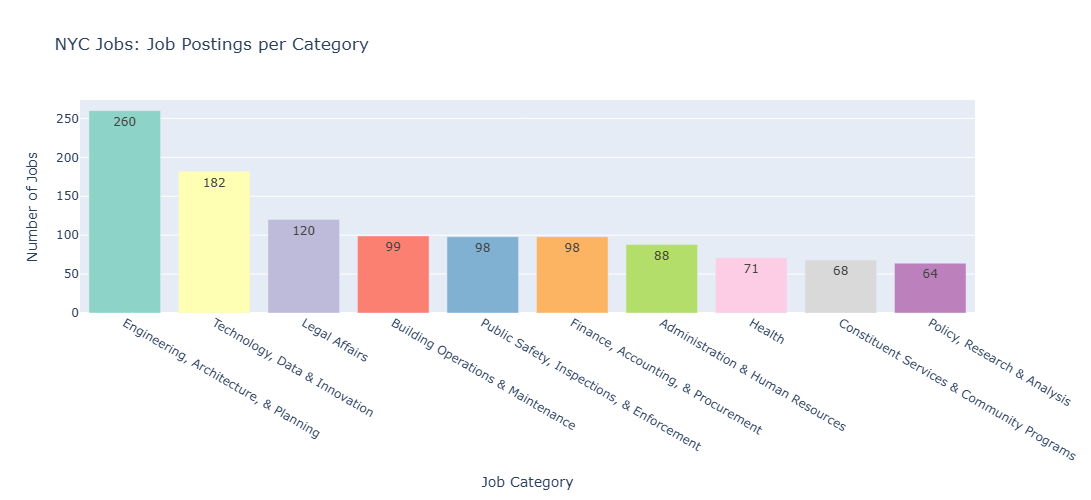

In [77]:
# KPIs

# 1. Job Postings per Category
post_per_category(cleaned_df)

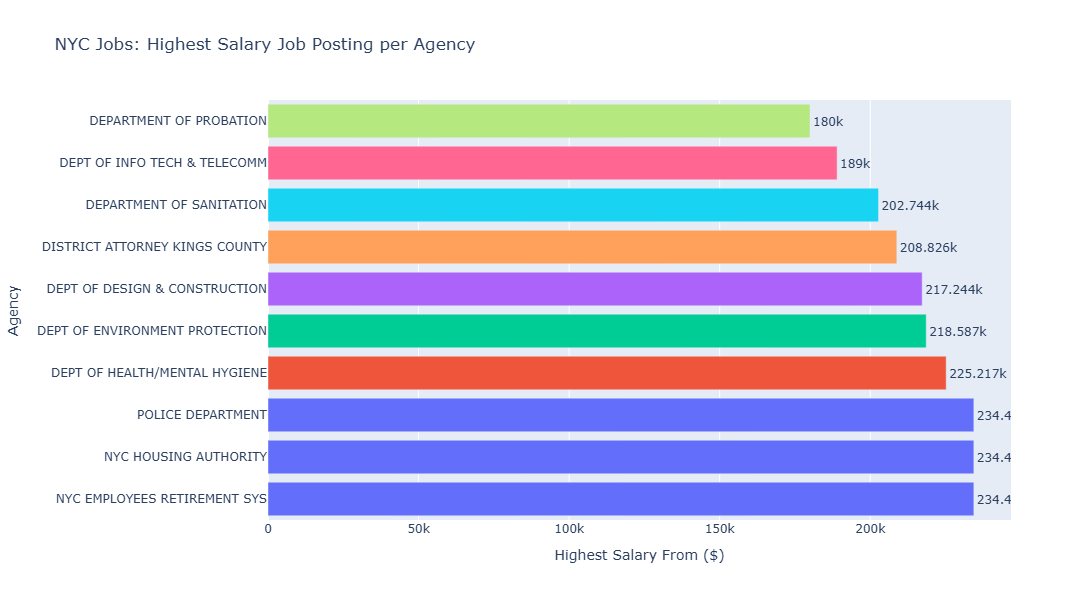

In [78]:
# 4. Highest Salary Job Posting per agency
highest_sal_per_agency(cleaned_df)

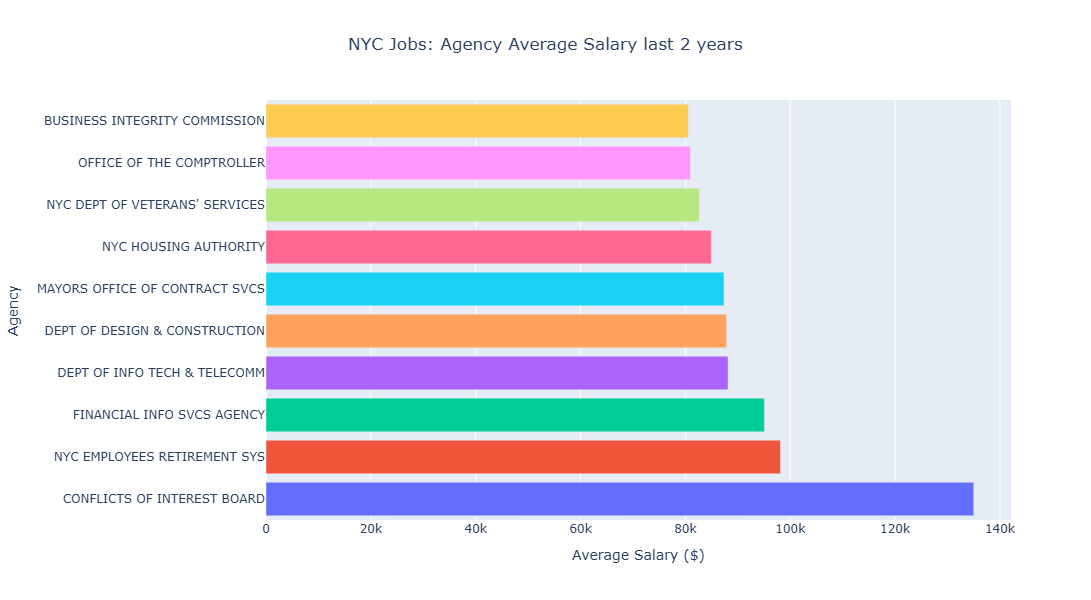

In [79]:
# 5. Average Salary of Job Posting per Agency for last 2 years
avg_sal(cleaned_df)

In [89]:
cleaned_df = cleaned_df.withColumn("year", year(col("posting_date"))).repartition(col("year"))
cleaned_df.write.partitionBy("year").mode("overwrite").parquet("output/job_posting_cleaned_df")

UnsupportedOperationException: getSubject is not supported